In [1]:
from google.colab import files
uploaded = files.upload()   # select churn-bigml-80.csv

Saving churn-bigml-80.csv to churn-bigml-80.csv


In [2]:
# ============================================================
# LEVEL 3 (ADVANCED) - Task 1: Build a Random Forest Classifier
# Dataset: Telecom Customer Churn (churn-bigml-80.csv)
# Tools: Python, scikit-learn, pandas, matplotlib
# ============================================================

# ── STEP 0: Install / Import Libraries ──────────────────────
# (All are pre-installed in Google Colab)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score,
                             precision_score, recall_score, accuracy_score)
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")


In [3]:
# ============================================================
# STEP 1: Load & Explore the Dataset
# ============================================================

# Upload the file in Colab using:
# from google.colab import files
# uploaded = files.upload()

df = pd.read_csv("churn-bigml-80.csv")   # <-- update filename if needed

print("=" * 60)
print("STEP 1: Dataset Overview")
print("=" * 60)
print(f"\nShape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nFirst 5 rows:")
print(df.head())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Distribution (Churn):")
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True).mul(100).round(2).astype(str) + " %")

STEP 1: Dataset Overview

Shape: 2666 rows × 20 columns

First 5 rows:
  State  Account length  Area code International plan Voice mail plan  \
0    KS             128        415                 No             Yes   
1    OH             107        415                 No             Yes   
2    NJ             137        415                 No              No   
3    OH              84        408                Yes              No   
4    OK              75        415                Yes              No   

   Number vmail messages  Total day minutes  Total day calls  \
0                     25              265.1              110   
1                     26              161.6              123   
2                      0              243.4              114   
3                      0              299.4               71   
4                      0              166.7              113   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0             45.07         

In [4]:
# ============================================================
# STEP 2: Data Preprocessing
# ============================================================

print("\n" + "=" * 60)
print("STEP 2: Preprocessing")
print("=" * 60)

df_clean = df.copy()

# Encode binary categorical columns
binary_cols = ["International plan", "Voice mail plan"]
le = LabelEncoder()
for col in binary_cols:
    df_clean[col] = le.fit_transform(df_clean[col])   # Yes=1, No=0

# Encode 'State' (drop it — too many categories, low predictive signal)
df_clean.drop(columns=["State", "Area code"], inplace=True)

# Encode target
df_clean["Churn"] = df_clean["Churn"].astype(int)   # True=1, False=0

print("Columns after preprocessing:")
print(df_clean.columns.tolist())
print("\nSample:")
print(df_clean.head(3))


STEP 2: Preprocessing
Columns after preprocessing:
['Account length', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls', 'Churn']

Sample:
   Account length  International plan  Voice mail plan  Number vmail messages  \
0             128                   0                1                     25   
1             107                   0                1                     26   
2             137                   0                0                      0   

   Total day minutes  Total day calls  Total day charge  Total eve minutes  \
0              265.1              110             45.07              197.4   
1              161.6              123             27.47              195.5   
2          

In [5]:
# ============================================================
# STEP 3: Feature / Target Split & Train-Test Split
# ============================================================

X = df_clean.drop(columns=["Churn"])
y = df_clean["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain size : {X_train.shape[0]} samples")
print(f"Test  size : {X_test.shape[0]} samples")



Train size : 2132 samples
Test  size : 534 samples


In [6]:
# ============================================================
# STEP 4: Baseline Random Forest (Default Hyperparameters)
# ============================================================

print("\n" + "=" * 60)
print("STEP 4: Baseline Random Forest")
print("=" * 60)

rf_base = RandomForestClassifier(n_estimators=100, random_state=42)
rf_base.fit(X_train, y_train)

y_pred_base = rf_base.predict(X_test)

print("\nBaseline Classification Report:")
print(classification_report(y_test, y_pred_base, target_names=["No Churn", "Churn"]))



STEP 4: Baseline Random Forest

Baseline Classification Report:
              precision    recall  f1-score   support

    No Churn       0.96      1.00      0.98       456
       Churn       0.98      0.73      0.84        78

    accuracy                           0.96       534
   macro avg       0.97      0.86      0.91       534
weighted avg       0.96      0.96      0.96       534



In [7]:
# ============================================================
# STEP 5: Hyperparameter Tuning with GridSearchCV
# ============================================================

print("\n" + "=" * 60)
print("STEP 5: Hyperparameter Tuning (GridSearchCV)")
print("=" * 60)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth":    [None, 10, 20],
    "min_samples_split": [2, 5],
    "max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",          # optimise for F1 (handles class imbalance well)
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nBest Parameters : {grid_search.best_params_}")
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")

best_rf = grid_search.best_estimator_


STEP 5: Hyperparameter Tuning (GridSearchCV)
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best Parameters : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 100}
Best CV F1 Score: 0.8243



STEP 6: Evaluate Tuned Model

Tuned Model Classification Report:
              precision    recall  f1-score   support

    No Churn       0.95      0.99      0.97       456
       Churn       0.93      0.72      0.81        78

    accuracy                           0.95       534
   macro avg       0.94      0.85      0.89       534
weighted avg       0.95      0.95      0.95       534

Accuracy  : 0.9513
Precision : 0.9333
Recall    : 0.7179
F1-Score  : 0.8116


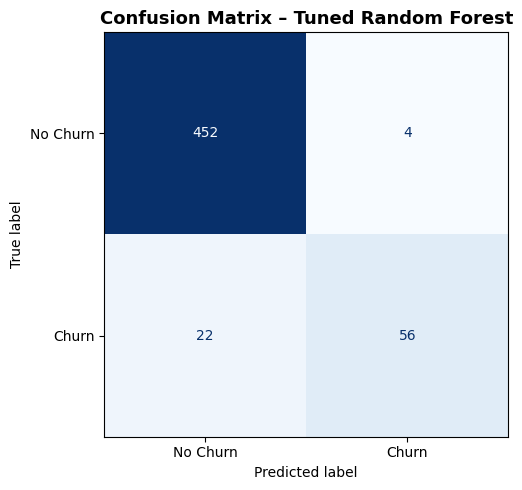

Saved: confusion_matrix.png


In [8]:
# ============================================================
# STEP 6: Evaluate the Tuned Model
# ============================================================

print("\n" + "=" * 60)
print("STEP 6: Evaluate Tuned Model")
print("=" * 60)

y_pred_best = best_rf.predict(X_test)

print("\nTuned Model Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=["No Churn", "Churn"]))

print(f"Accuracy  : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_best):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_best):.4f}")

# ── Confusion Matrix ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["No Churn", "Churn"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix – Tuned Random Forest", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("Saved: confusion_matrix.png")


STEP 7: 5-Fold Cross-Validation
Accuracy  : 0.9539 ± 0.0076
Precision : 0.9349 ± 0.0340
Recall    : 0.7345 ± 0.0418
F1-Score  : 0.8220 ± 0.0327


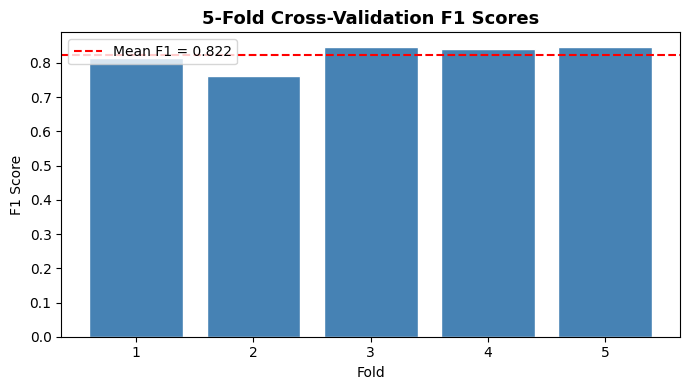

Saved: cross_validation_f1.png


In [9]:
# ============================================================
# STEP 7: Cross-Validation
# ============================================================

print("\n" + "=" * 60)
print("STEP 7: 5-Fold Cross-Validation")
print("=" * 60)

metrics = {
    "Accuracy" : "accuracy",
    "Precision": "precision",
    "Recall"   : "recall",
    "F1-Score" : "f1"
}

for name, scorer in metrics.items():
    scores = cross_val_score(best_rf, X, y, cv=5, scoring=scorer)
    print(f"{name:10s}: {scores.mean():.4f} ± {scores.std():.4f}")


# ── Cross-Val F1 Plot ────────────────────────────────────────
f1_scores = cross_val_score(best_rf, X, y, cv=5, scoring="f1")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, 6), f1_scores, color="steelblue", edgecolor="white")
ax.axhline(f1_scores.mean(), color="red", linestyle="--", label=f"Mean F1 = {f1_scores.mean():.3f}")
ax.set_xlabel("Fold")
ax.set_ylabel("F1 Score")
ax.set_title("5-Fold Cross-Validation F1 Scores", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("cross_validation_f1.png", dpi=150)
plt.show()
print("Saved: cross_validation_f1.png")


STEP 8: Feature Importance Analysis

Top 10 Most Important Features:
               Feature  Importance
      Total day charge    0.147012
     Total day minutes    0.133673
Customer service calls    0.131776
    International plan    0.102787
      Total eve charge    0.069502
     Total eve minutes    0.060137
      Total intl calls    0.052891
     Total intl charge    0.041463
    Total intl minutes    0.037341
   Total night minutes    0.036154


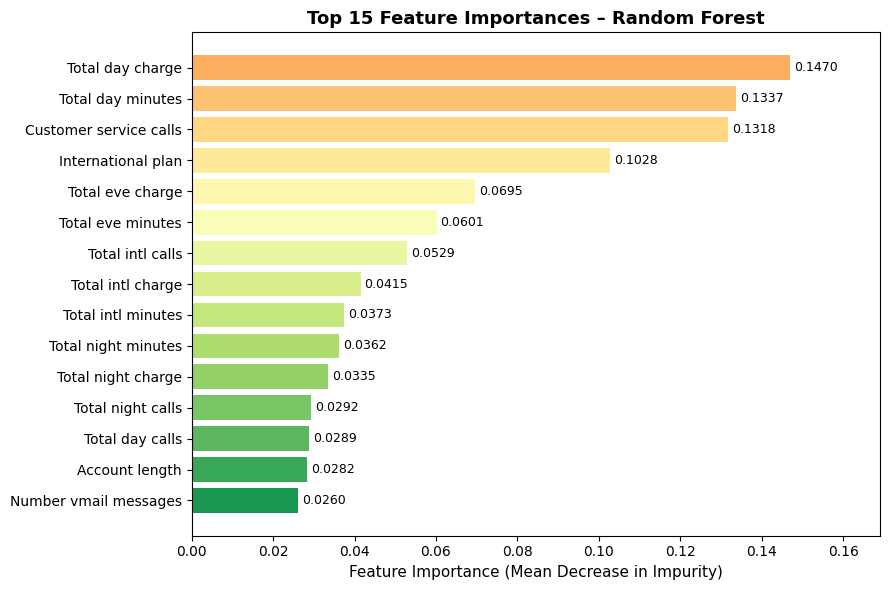

Saved: feature_importance.png


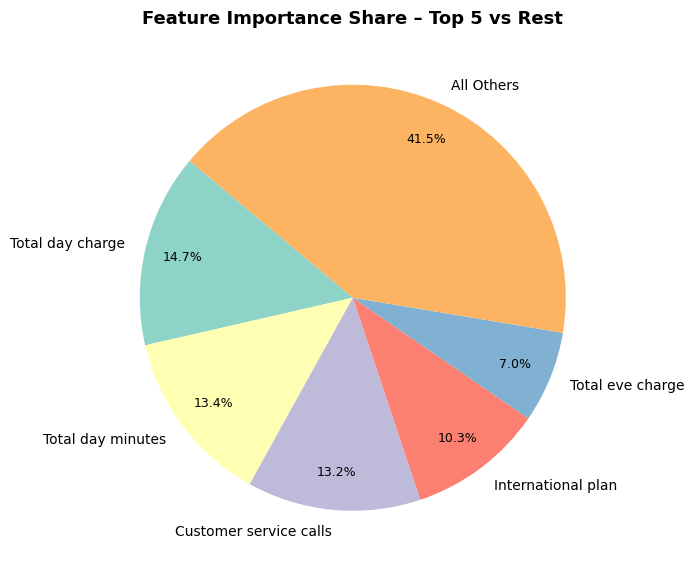

Saved: feature_importance_pie.png


In [10]:
# ============================================================
# STEP 8: Feature Importance Analysis
# ============================================================

print("\n" + "=" * 60)
print("STEP 8: Feature Importance Analysis")
print("=" * 60)

importances = best_rf.feature_importances_
feat_df = pd.DataFrame({
    "Feature"   : X.columns,
    "Importance": importances
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print("\nTop 10 Most Important Features:")
print(feat_df.head(10).to_string(index=False))

# ── Horizontal Bar Chart ─────────────────────────────────────
top_n = 15
top_feat = feat_df.head(top_n)

fig, ax = plt.subplots(figsize=(9, 6))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, top_n))[::-1]
bars = ax.barh(top_feat["Feature"][::-1], top_feat["Importance"][::-1], color=colors)

for bar, val in zip(bars, top_feat["Importance"][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=9)

ax.set_xlabel("Feature Importance (Mean Decrease in Impurity)", fontsize=11)
ax.set_title(f"Top {top_n} Feature Importances – Random Forest", fontsize=13, fontweight="bold")
ax.set_xlim(0, top_feat["Importance"].max() * 1.15)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()
print("Saved: feature_importance.png")


# ── Pie Chart: Top 5 vs Rest ─────────────────────────────────
top5 = feat_df.head(5)
others_sum = feat_df.iloc[5:]["Importance"].sum()
pie_data = list(top5["Importance"]) + [others_sum]
pie_labels = list(top5["Feature"]) + ["All Others"]

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    pie_data, labels=pie_labels, autopct="%1.1f%%",
    startangle=140, pctdistance=0.82,
    colors=plt.cm.Set3.colors[:len(pie_data)]
)
for t in autotexts:
    t.set_fontsize(9)
ax.set_title("Feature Importance Share – Top 5 vs Rest", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("feature_importance_pie.png", dpi=150)
plt.show()
print("Saved: feature_importance_pie.png")



STEP 9: Model Comparison Summary
             Accuracy  Precision  Recall  F1-Score
Model                                             
Baseline RF    0.9588     0.9828  0.7308    0.8382
Tuned RF       0.9513     0.9333  0.7179    0.8116


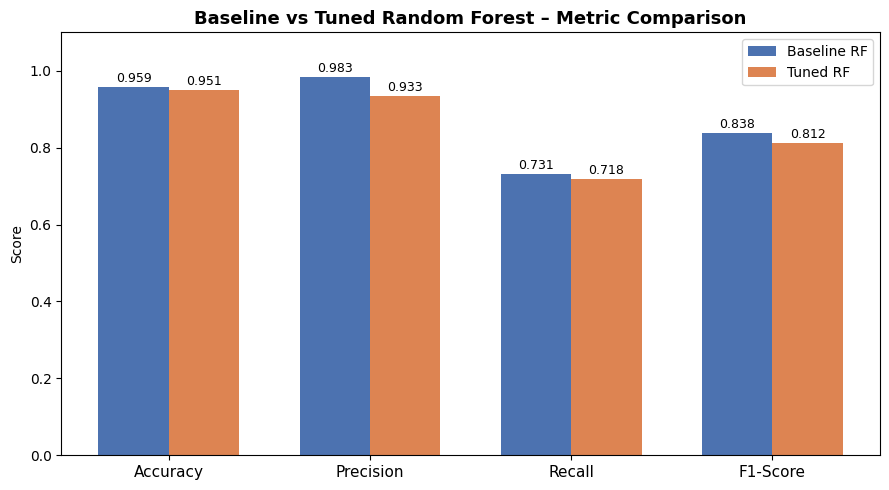

Saved: model_comparison.png

ALL STEPS COMPLETE!

SUMMARY
-------
1. Loaded & explored the Churn dataset (20 features, 1 target).
2. Preprocessed: encoded categoricals, dropped low-signal columns.
3. Split data: 80% train / 20% test (stratified).
4. Trained a Baseline Random Forest.
5. Tuned hyperparameters with GridSearchCV (5-fold CV, F1 scoring).
6. Evaluated with Precision, Recall, F1, Confusion Matrix.
7. Validated with 5-fold Cross-Validation.
8. Identified most important features for churn prediction.
9. Compared Baseline vs Tuned model visually.



In [11]:
# ============================================================
# STEP 9: Model Comparison Summary
# ============================================================

print("\n" + "=" * 60)
print("STEP 9: Model Comparison Summary")
print("=" * 60)

results = {
    "Model"    : ["Baseline RF", "Tuned RF"],
    "Accuracy" : [accuracy_score(y_test, y_pred_base),
                  accuracy_score(y_test, y_pred_best)],
    "Precision": [precision_score(y_test, y_pred_base),
                  precision_score(y_test, y_pred_best)],
    "Recall"   : [recall_score(y_test, y_pred_base),
                  recall_score(y_test, y_pred_best)],
    "F1-Score" : [f1_score(y_test, y_pred_base),
                  f1_score(y_test, y_pred_best)],
}

summary_df = pd.DataFrame(results).set_index("Model")
print(summary_df.round(4))

# ── Bar chart comparison ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(summary_df.columns))
width = 0.35
bars1 = ax.bar(x - width/2, summary_df.loc["Baseline RF"], width,
               label="Baseline RF", color="#4C72B0")
bars2 = ax.bar(x + width/2, summary_df.loc["Tuned RF"], width,
               label="Tuned RF", color="#DD8452")

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(summary_df.columns, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Baseline vs Tuned Random Forest – Metric Comparison",
             fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()
print("Saved: model_comparison.png")

print("\n" + "=" * 60)
print("ALL STEPS COMPLETE!")
print("=" * 60)
print("""
SUMMARY
-------
1. Loaded & explored the Churn dataset (20 features, 1 target).
2. Preprocessed: encoded categoricals, dropped low-signal columns.
3. Split data: 80% train / 20% test (stratified).
4. Trained a Baseline Random Forest.
5. Tuned hyperparameters with GridSearchCV (5-fold CV, F1 scoring).
6. Evaluated with Precision, Recall, F1, Confusion Matrix.
7. Validated with 5-fold Cross-Validation.
8. Identified most important features for churn prediction.
9. Compared Baseline vs Tuned model visually.
""")
